# Proyecto Integrador: Clasificación de Anemia en Niños Menores de 5 años
**Dataset:** SIEN - Ayacucho, Perú  
**Problema:** Clasificación multiclase del diagnóstico de anemia  
**Alumno:** Proyecto Universitario de Ciencia de Datos

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import gc

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## TAREA 1: Comprensión del Dataset

In [2]:
df = pd.read_csv('../datos/anemia.csv')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print()
df.head()

Filas: 35967
Columnas: 37



,sw,Diresa,Red,Microred,EESS,Dpto_EESS,Prov_EESS,Dist_EESS,Ubigeo_EESS,Renipress,...,Hemoglobina,FechaAtencion,FechaNacimiento,UbigeoREN,DepartamentoREN,ProvinciaREN,DistritoREN,AlturaREN,Hbc,Dx_anemia
0,1,AYACUCHO,AYACUCHO CENTRO,VILCASHUAMAN,I-1 - 00021259 - PUESTO DE SALUD OCCO,AYACUCHO,VILCAS HUAMAN,INDEPENDENCIA,51106,21259,...,15.2,1/27/2025,10/17/2020,51106,AYACUCHO,VILCAS HUAMAN,INDEPENDENCIA,3606,12.776696,Normal
1,1,AYACUCHO,AYACUCHO CENTRO,VILCASHUAMAN,I-1 - 00006614 - PUESTO DE SALUD POMACOCHA,AYACUCHO,VILCAS HUAMAN,VISCHONGO,51108,6614,...,15.2,5/7/2025,8/29/2020,51108,AYACUCHO,VILCAS HUAMAN,VISCHONGO,3150,13.126229,Normal
2,1,AYACUCHO,AYACUCHO CENTRO,VICTOR FAJARDO,I-1 - 00003830 - PUESTO DE SALUD TIQUIHUA,AYACUCHO,VICTOR FAJARDO,HUALLA,51010,3830,...,14.5,5/29/2025,12/17/2020,51010,AYACUCHO,VICTOR FAJARDO,HUAYA,3423,12.218468,Normal
3,1,AYACUCHO,AYACUCHO CENTRO,POMABAMBA,I-3 - 00003502 - CENTRO DE SALUD CHUSCHI,AYACUCHO,CANGALLO,CHUSCHI,50202,3502,...,14.6,3/22/2025,9/17/2020,50202,AYACUCHO,CANGALLO,CHUSCHI,3157,12.520958,Normal
4,1,AYACUCHO,HUAMANGA,CHONTACA,I-1 - 00003545 - PUESTO DE SALUD CCOLLCCA,AYACUCHO,HUAMANGA,ACOCRO,50102,3545,...,11.4,2/14/2025,6/8/2020,50102,AYACUCHO,HUAMANGA,ACOCRO,3251,9.249886,Anemia Moderada


In [3]:
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores faltantes ===')
print(df.isnull().sum())
print()
print('=== Duplicados ===' )
print(f'Filas duplicadas: {df.duplicated().sum()}')

=== Tipos de datos ===
sw                    int64
Diresa                  str
Red                     str
Microred                str
EESS                    str
Dpto_EESS               str
Prov_EESS               str
Dist_EESS               str
Ubigeo_EESS           int64
Renipress             int64
Pais                    str
Sexo                    str
EdadMeses           float64
UbigeoPN                str
DepartamentoPN          str
ProvinciaPN             str
DistritoPN              str
CentroPobladoPN         str
Juntos                  str
SIS                     str
Pin                     str
Qaliwarma               str
FechaHemoglobina        str
Cred                  int64
Suplementacion        int64
Consejeria            int64
Sesion                int64
Hemoglobina         float64
FechaAtencion           str
FechaNacimiento         str
UbigeoREN             int64
DepartamentoREN         str
ProvinciaREN            str
DistritoREN             str
AlturaREN             int

In [4]:
print('=== Variables numéricas ===')
print(df.select_dtypes(include='number').columns.tolist())
print()
print('=== Variables categóricas ===')
print(df.select_dtypes(include='object').columns.tolist())
print()
print('=== Variable objetivo: Dx_anemia ===')
print(df['Dx_anemia'].value_counts())

=== Variables numéricas ===
['sw', 'Ubigeo_EESS', 'Renipress', 'EdadMeses', 'Cred', 'Suplementacion', 'Consejeria', 'Sesion', 'Hemoglobina', 'UbigeoREN', 'AlturaREN', 'Hbc']

=== Variables categóricas ===
['Diresa', 'Red', 'Microred', 'EESS', 'Dpto_EESS', 'Prov_EESS', 'Dist_EESS', 'Pais', 'Sexo', 'UbigeoPN', 'DepartamentoPN', 'ProvinciaPN', 'DistritoPN', 'CentroPobladoPN', 'Juntos', 'SIS', 'Pin', 'Qaliwarma', 'FechaHemoglobina', 'FechaAtencion', 'FechaNacimiento', 'DepartamentoREN', 'ProvinciaREN', 'DistritoREN', 'Dx_anemia']

=== Variable objetivo: Dx_anemia ===
Dx_anemia
Normal             29323
Anemia Leve         5340
Anemia Moderada     1293
Anemia Severa         11
Name: count, dtype: int64


**Justificación:**  
La variable objetivo es `Dx_anemia`, que clasifica el diagnóstico de anemia en 4 categorías: Normal, Anemia Leve, Anemia Moderada y Anemia Severa. El problema es de **clasificación multiclase**. Se utilizarán como predictores variables clínicas y socioeconómicas disponibles: hemoglobina corregida (`Hbc`), edad en meses (`EdadMeses`), altitud (`AlturaREN`), sexo, y participación en programas sociales.

## TAREA 2: Preprocesamiento

In [5]:
# Selección de variables relevantes
# Se descartan columnas administrativas/geográficas redundantes y campos constantes
features = ['Sexo', 'EdadMeses', 'AlturaREN', 'Hbc', 'Hemoglobina',
            'Cred', 'Suplementacion', 'Juntos', 'SIS', 'Qaliwarma']
target = 'Dx_anemia'

data = df[features + [target]].copy()
print('Variables seleccionadas:', features)
print('Variable objetivo:', target)
print('Shape:', data.shape)

Variables seleccionadas: ['Sexo', 'EdadMeses', 'AlturaREN', 'Hbc', 'Hemoglobina', 'Cred', 'Suplementacion', 'Juntos', 'SIS', 'Qaliwarma']
Variable objetivo: Dx_anemia
Shape: (35967, 11)


In [6]:
# Limpieza de columnas con espacios en blanco (valores ' ')
for col in ['Juntos', 'SIS', 'Qaliwarma']:
    data[col] = data[col].replace(' ', '0')
    data[col] = data[col].astype(int)

# Codificación de Sexo: M=1, F=0
data['Sexo'] = data['Sexo'].map({'M': 1, 'F': 0})

# Verificar que no queden nulos
print('Nulos tras limpieza:')
print(data.isnull().sum())

Nulos tras limpieza:
Sexo              0
EdadMeses         0
AlturaREN         0
Hbc               0
Hemoglobina       0
Cred              0
Suplementacion    0
Juntos            0
SIS               0
Qaliwarma         0
Dx_anemia         0
dtype: int64


In [7]:
# Detección de outliers en variables numéricas continuas
for col in ['EdadMeses', 'AlturaREN', 'Hbc', 'Hemoglobina']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {outliers} outliers ({outliers/len(data)*100:.1f}%)')

EdadMeses: 0 outliers (0.0%)
AlturaREN: 4338 outliers (12.1%)
Hbc: 1129 outliers (3.1%)
Hemoglobina: 555 outliers (1.5%)


In [8]:
# Codificación de la variable objetivo con LabelEncoder
le = LabelEncoder()
data['target'] = le.fit_transform(data[target])
print('Clases codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

X = data.drop(columns=[target, 'target'])
y = data['target']

# División train/test 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Clases codificadas: {'Anemia Leve': 0, 'Anemia Moderada': 1, 'Anemia Severa': 2, 'Normal': 3}
Train: 28773 muestras
Test:  7194 muestras


## TAREA 3: Análisis Exploratorio

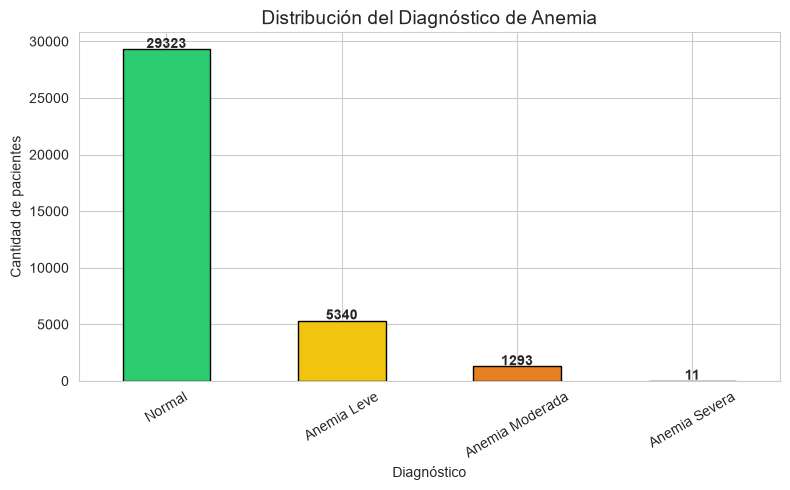

Conclusión: La mayoría de pacientes son clasificados como Normal (81.5%). Existe un desbalance marcado.


In [9]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['Dx_anemia'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribución del Diagnóstico de Anemia', fontsize=14)
ax.set_xlabel('Diagnóstico')
ax.set_ylabel('Cantidad de pacientes')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Conclusión: La mayoría de pacientes son clasificados como Normal (81.5%). Existe un desbalance marcado.')

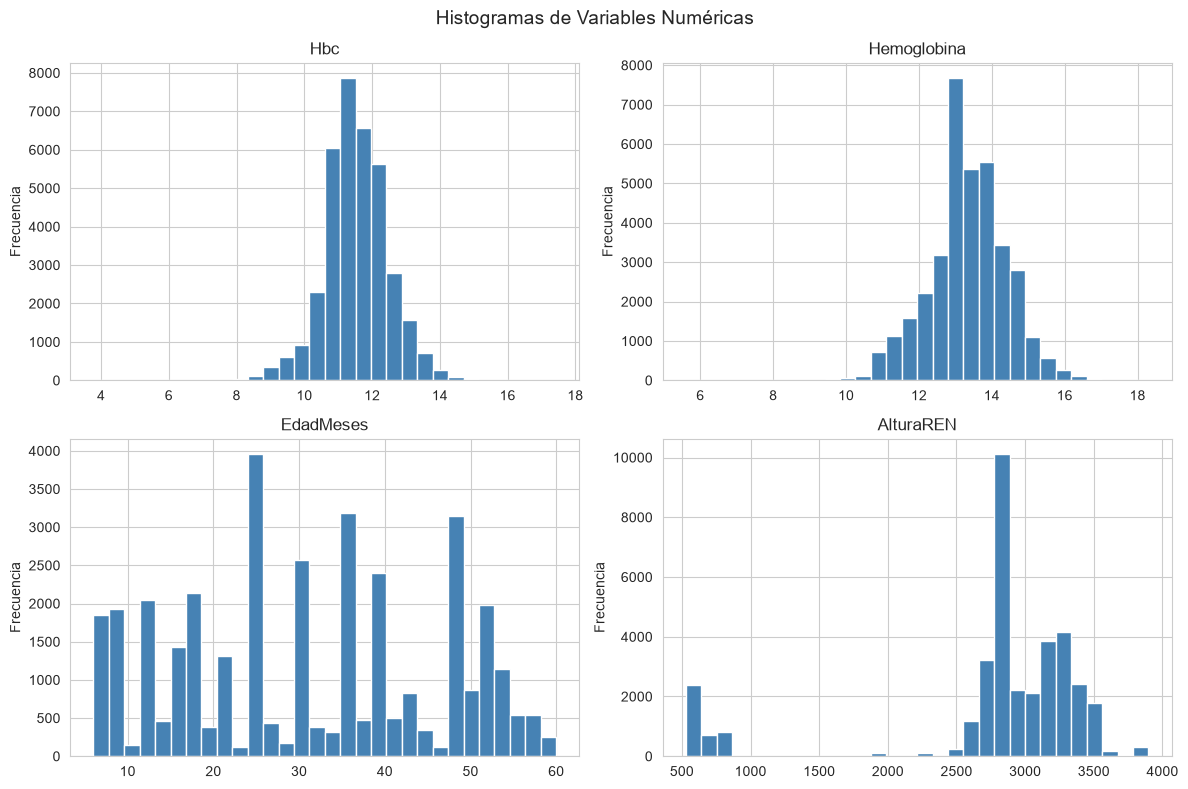

Conclusión: Hbc y Hemoglobina muestran distribución aproximadamente normal con cola izquierda. EdadMeses es relativamente uniforme. AlturaREN concentra valores entre 2500-3500 msnm (zona andina de Ayacucho).


In [10]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
vars_num = ['Hbc', 'Hemoglobina', 'EdadMeses', 'AlturaREN']
for ax, col in zip(axes.flatten(), vars_num):
    data[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
plt.suptitle('Histogramas de Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()
print('Conclusión: Hbc y Hemoglobina muestran distribución aproximadamente normal con cola izquierda. EdadMeses es relativamente uniforme. AlturaREN concentra valores entre 2500-3500 msnm (zona andina de Ayacucho).')

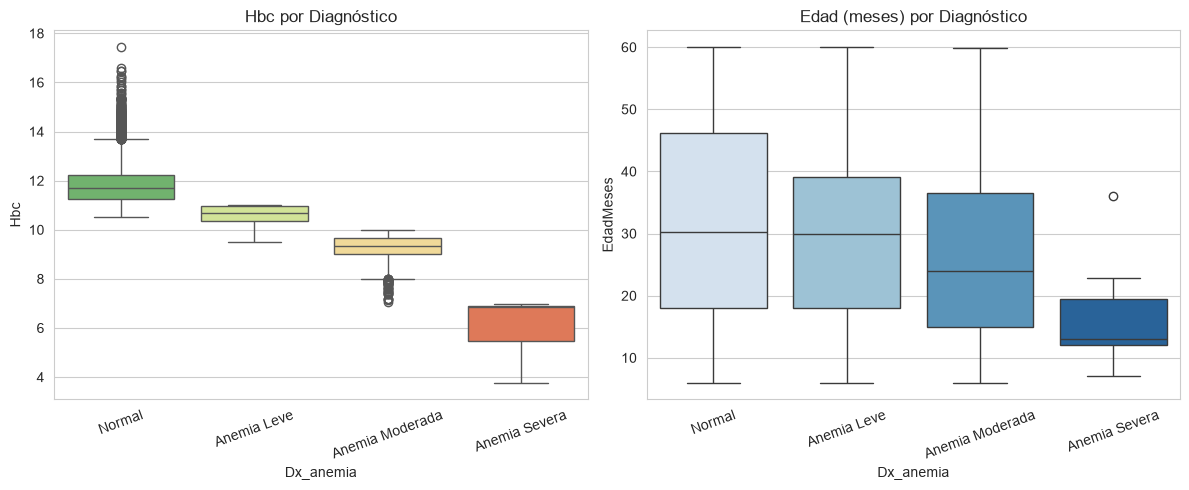

Conclusión: Hbc discrimina claramente entre diagnósticos — es el predictor más relevante. La edad no muestra diferencias marcadas.


In [11]:
# Boxplots por diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['Normal', 'Anemia Leve', 'Anemia Moderada', 'Anemia Severa']
temp = df[['Dx_anemia', 'Hbc', 'EdadMeses']].copy()

sns.boxplot(data=temp, x='Dx_anemia', y='Hbc', order=order,
            palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Hbc por Diagnóstico')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=temp, x='Dx_anemia', y='EdadMeses', order=order,
            palette='Blues', ax=axes[1])
axes[1].set_title('Edad (meses) por Diagnóstico')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print('Conclusión: Hbc discrimina claramente entre diagnósticos — es el predictor más relevante. La edad no muestra diferencias marcadas.')

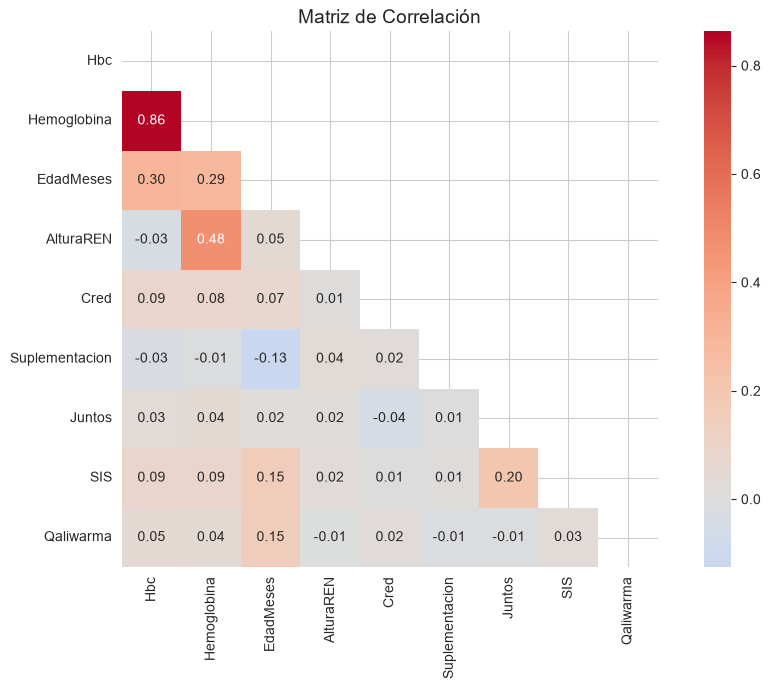

Conclusión: Hbc y Hemoglobina tienen correlación muy alta (>0.99), se puede eliminar Hemoglobina para evitar multicolinealidad. Las variables de programas sociales tienen correlación baja entre sí.


In [12]:
# Matriz de correlación
corr = data[['Hbc', 'Hemoglobina', 'EdadMeses', 'AlturaREN',
             'Cred', 'Suplementacion', 'Juntos', 'SIS', 'Qaliwarma']].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()
print('Conclusión: Hbc y Hemoglobina tienen correlación muy alta (>0.99), se puede eliminar Hemoglobina para evitar multicolinealidad. Las variables de programas sociales tienen correlación baja entre sí.')

In [13]:
# Eliminar Hemoglobina por alta correlación con Hbc
X_train = X_train.drop(columns=['Hemoglobina'])
X_test = X_test.drop(columns=['Hemoglobina'])
print('Hemoglobina eliminada por multicolinealidad con Hbc.')
print('Features finales:', X_train.columns.tolist())

Hemoglobina eliminada por multicolinealidad con Hbc.
Features finales: ['Sexo', 'EdadMeses', 'AlturaREN', 'Hbc', 'Cred', 'Suplementacion', 'Juntos', 'SIS', 'Qaliwarma']


## TAREA 4: Análisis del Desbalance de Clases

=== Distribución de Clases ===
                 Frecuencia  Porcentaje (%)
Dx_anemia                                  
Normal                29323           81.53
Anemia Leve            5340           14.85
Anemia Moderada        1293            3.59
Anemia Severa            11            0.03


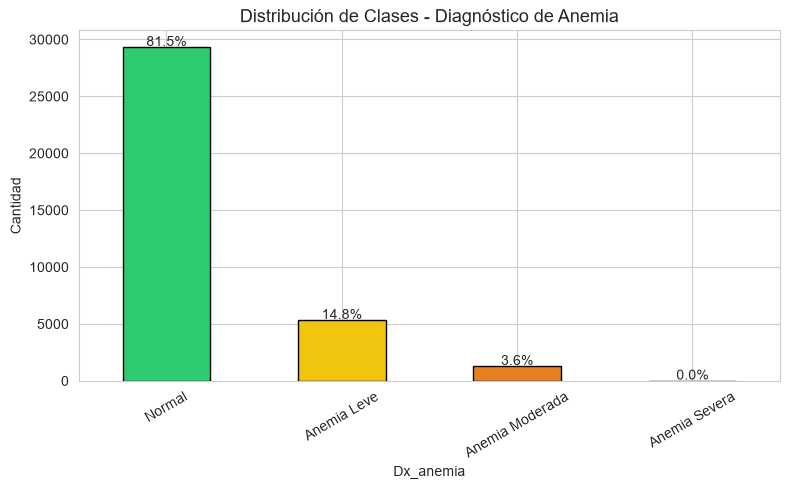

In [14]:
print('=== Distribución de Clases ===')
dist = df['Dx_anemia'].value_counts()
dist_pct = df['Dx_anemia'].value_counts(normalize=True) * 100

tabla = pd.DataFrame({'Frecuencia': dist, 'Porcentaje (%)': dist_pct.round(2)})
print(tabla)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
dist.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribución de Clases - Diagnóstico de Anemia', fontsize=13)
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=30)
for i, (v, p) in enumerate(zip(dist, dist_pct)):
    ax.text(i, v + 100, f'{p:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## TAREA 5: Clases Extremadamente Minoritarias

**Anemia Severa tiene solo 11 registros (0.03% del total).**  
Esto representa un problema grave:
- El modelo no puede aprender correctamente con tan pocos ejemplos
- Alta probabilidad de sobreajuste en esa clase
- Métricas de precision/recall/F1 para esa clase serán poco confiables
- Con validación cruzada (5 folds), algunos folds tendrían 0 o 1 ejemplo de esa clase

### Escenarios evaluados:

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)

# Escenario A: 4 clases originales
scores_a = cross_val_score(rf_base, X_train, y_train, cv=skf,
                           scoring='f1_macro', n_jobs=1)
print(f'Escenario A (4 clases originales) - F1 Macro: {scores_a.mean():.4f} ± {scores_a.std():.4f}')

Escenario A (4 clases originales) - F1 Macro: 0.8158 ± 0.0818


In [16]:
# Escenario C: Clasificación binaria (Normal vs Anemia)
y_bin = y_train.map({0: 0, 1: 1, 2: 1, 3: 1})  # 0=Normal, 1=Anemia (cualquier nivel)
scores_c = cross_val_score(rf_base, X_train, y_bin, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                           scoring='f1_macro', n_jobs=1)
print(f'Escenario C (binario: Normal vs Anemia) - F1 Macro: {scores_c.mean():.4f} ± {scores_c.std():.4f}')

Escenario C (binario: Normal vs Anemia) - F1 Macro: 0.9999 ± 0.0003


In [17]:
# Escenario B: Agrupar Severa con Moderada => 3 clases
# Mapeo: Normal=0, Leve=1, Moderada+Severa=2
# Clases originales LabelEncoder: Anemia Leve=0, Anemia Moderada=1, Anemia Severa=2, Normal=3
print('Clases codificadas:', dict(zip(range(len(le.classes_)), le.classes_)))
y_3c = y_train.map({3: 0, 0: 1, 1: 2, 2: 2})  # Normal=0, Leve=1, Mod+Sev=2
scores_b = cross_val_score(rf_base, X_train, y_3c, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                           scoring='f1_macro', n_jobs=1)
print(f'Escenario B (3 clases: agrupa Severa+Moderada) - F1 Macro: {scores_b.mean():.4f} ± {scores_b.std():.4f}')

Clases codificadas: {0: 'Anemia Leve', 1: 'Anemia Moderada', 2: 'Anemia Severa', 3: 'Normal'}
Escenario B (3 clases: agrupa Severa+Moderada) - F1 Macro: 0.9998 ± 0.0004


In [18]:
print('\n=== COMPARACIÓN DE ESCENARIOS ===')
print(f'Escenario A (4 clases): {scores_a.mean():.4f}')
print(f'Escenario B (3 clases): {scores_b.mean():.4f}')
print(f'Escenario C (binario):  {scores_c.mean():.4f}')
print()
print('Decisión: Se continúa con Escenario A (4 clases) porque:')
print(' - Mantiene la granularidad clínica del diagnóstico')
print(' - El desbalance se tratará con class_weight y SMOTE')
print(' - Tiene valor real para médicos y gestores de salud')


=== COMPARACIÓN DE ESCENARIOS ===
Escenario A (4 clases): 0.8158
Escenario B (3 clases): 0.9998
Escenario C (binario):  0.9999

Decisión: Se continúa con Escenario A (4 clases) porque:
 - Mantiene la granularidad clínica del diagnóstico
 - El desbalance se tratará con class_weight y SMOTE
 - Tiene valor real para médicos y gestores de salud


## TAREA 6: Tratamiento del Desbalance

In [19]:
# Técnica: SMOTE para sobremuestrear clases minoritarias
# Se aplica solo al conjunto de entrenamiento
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Convertir a float32 para reducir uso de RAM a la mitad (float64 → float32)
X_train_sm = X_train_sm.astype(np.float32)
X_test = X_test.astype(np.float32)
gc.collect()

print('Distribución ANTES de SMOTE:')
print(pd.Series(y_train).value_counts().sort_index())
print()
print('Distribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_sm).value_counts().sort_index())

print()
for i, cls in enumerate(le.classes_):
    print(f'{i} ({cls}): {(y_train_sm == i).sum()} muestras')

Distribución ANTES de SMOTE:
target
0     4272
1     1034
2        9
3    23458
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
target
0    23458
1    23458
2    23458
3    23458
Name: count, dtype: int64

0 (Anemia Leve): 23458 muestras
1 (Anemia Moderada): 23458 muestras
2 (Anemia Severa): 23458 muestras
3 (Normal): 23458 muestras


## TAREA 7: Modelado

In [20]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t1 = time.time()
    y_pred = modelo.predict(X_te)
    
    return {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1': round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1 Macro': round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Tiempo (s)': round(t1 - t0, 2)
    }

resultados = []

# --- Modelos base (sin balanceo) ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)
xgb = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                    use_label_encoder=False, eval_metric='mlogloss', verbosity=0, nthread=1)

resultados.append(evaluar_modelo('LR (base)', lr, X_train, y_train, X_test, y_test))
resultados.append(evaluar_modelo('RF (base)', rf, X_train, y_train, X_test, y_test))
resultados.append(evaluar_modelo('XGB (base)', xgb, X_train, y_train, X_test, y_test))
gc.collect()
print('Modelos base entrenados.')

Modelos base entrenados.


In [21]:
# --- Modelos con SMOTE ---
lr_sm = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf_sm = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)
xgb_sm = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                       use_label_encoder=False, eval_metric='mlogloss', verbosity=0, nthread=1)

resultados.append(evaluar_modelo('LR (SMOTE)', lr_sm, X_train_sm, y_train_sm, X_test, y_test))
resultados.append(evaluar_modelo('RF (SMOTE)', rf_sm, X_train_sm, y_train_sm, X_test, y_test))
resultados.append(evaluar_modelo('XGB (SMOTE)', xgb_sm, X_train_sm, y_train_sm, X_test, y_test))
gc.collect()
print('Modelos con SMOTE entrenados.')

Modelos con SMOTE entrenados.


## TAREA 8: Validación Cruzada

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_cv = {
    'LR (SMOTE)': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_sm, y_train_sm),
    'RF (SMOTE)': (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1), X_train_sm, y_train_sm),
    'XGB (SMOTE)': (XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                   use_label_encoder=False, eval_metric='mlogloss', verbosity=0, nthread=1), X_train_sm, y_train_sm)
}

print('=== Validación Cruzada (F1 Macro, 5 folds) ===')
for nombre, (modelo, Xtr, ytr) in modelos_cv.items():
    # n_jobs=1 evita forks paralelos que duplican dataset en memoria
    scores = cross_val_score(modelo, Xtr, ytr, cv=skf, scoring='f1_macro', n_jobs=1)
    print(f'{nombre}: {scores.mean():.4f} ± {scores.std():.4f}')
    gc.collect()

=== Validación Cruzada (F1 Macro, 5 folds) ===
LR (SMOTE): 0.7211 ± 0.0078
RF (SMOTE): 0.9997 ± 0.0001
XGB (SMOTE): 0.9996 ± 0.0001


## TAREA 9: Ajuste de Hiperparámetros

In [23]:
# Random Forest - GridSearchCV
# Parámetros ajustados: n_estimators (más árboles = más estabilidad),
# max_depth (controla sobreajuste), min_samples_leaf (evita hojas ruidosas)
#
# NOTA MEMORIA: se usa n_jobs=1 en el RF Y en GridSearchCV.
# Combinar n_jobs=-1 en ambos multiplica los procesos en paralelo y
# agota la RAM con datasets grandes. El grid también es reducido
# a 8 combinaciones (2x2x2) para mantener tiempos razonables.
import gc
gc.collect()

param_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 3]
}

# n_jobs=1 en el estimador base: el paralelismo lo gestiona GridSearchCV
# n_jobs=1 en GridSearchCV: evita forks que duplican el dataset en RAM
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_rf, cv=3, scoring='f1_macro', n_jobs=1, verbose=1
)
gs_rf.fit(X_train_sm, y_train_sm)
print('Mejores parámetros RF:', gs_rf.best_params_)
print('Mejor F1 Macro CV:', round(gs_rf.best_score_, 4))
gc.collect()

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros RF: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 150}
Mejor F1 Macro CV: 0.9997


295

In [24]:
# XGBoost - RandomizedSearchCV
# Parámetros ajustados: learning_rate (velocidad de aprendizaje),
# max_depth (profundidad del árbol), n_estimators (número de iteraciones),
# subsample (fracción de datos por árbol, reduce sobreajuste)
#
# NOTA MEMORIA: n_jobs=1 en XGBClassifier y en RandomizedSearchCV.
# n_iter=10 (reducido de 15) para menor tiempo y memoria.
# nthread=1 en XGB desactiva su paralelismo interno durante el search.
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.9]
}

rs_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False,
                  eval_metric='mlogloss', verbosity=0, nthread=1),
    param_xgb, n_iter=10, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=1, verbose=1
)
rs_xgb.fit(X_train_sm, y_train_sm)
print('Mejores parámetros XGB:', rs_xgb.best_params_)
print('Mejor F1 Macro CV:', round(rs_xgb.best_score_, 4))
gc.collect()

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros XGB: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}
Mejor F1 Macro CV: 0.9996


362

In [25]:
# Evaluar modelos optimizados en test
resultados.append(evaluar_modelo('RF (Tuned)', gs_rf.best_estimator_, X_train_sm, y_train_sm, X_test, y_test))
resultados.append(evaluar_modelo('XGB (Tuned)', rs_xgb.best_estimator_, X_train_sm, y_train_sm, X_test, y_test))
print('Modelos optimizados evaluados.')

Modelos optimizados evaluados.


## TAREA 10: Comparación de Modelos

In [26]:
df_res = pd.DataFrame(resultados)
df_res = df_res.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print('=== TABLA COMPARATIVA DE MODELOS ===')
print(df_res.to_string(index=False))

=== TABLA COMPARATIVA DE MODELOS ===
     Modelo  Accuracy  Precision  Recall     F1  F1 Macro  Tiempo (s)
 RF (Tuned)    0.9993     0.9994  0.9993 0.9993    0.9485       19.91
 RF (SMOTE)    0.9990     0.9991  0.9990 0.9990    0.9478       12.55
XGB (Tuned)    0.9990     0.9991  0.9990 0.9991    0.8466       21.07
XGB (SMOTE)    0.9989     0.9990  0.9989 0.9989    0.8465        5.84
  RF (base)    0.9994     0.9992  0.9994 0.9993    0.7488        3.04
 XGB (base)    0.9992     0.9989  0.9992 0.9990    0.7466        2.62
 LR (SMOTE)    0.6440     0.7856  0.6440 0.6909    0.4570        8.91
  LR (base)    0.8597     0.8311  0.8597 0.8316    0.4246       11.93


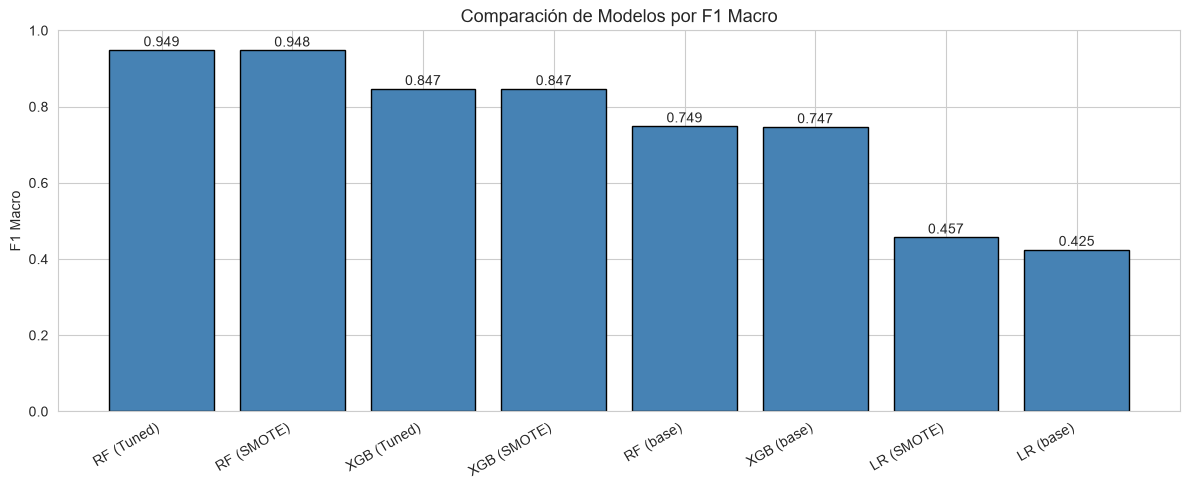

In [27]:
# Gráfico de comparación
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_res))
ax.bar(x, df_res['F1 Macro'], color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Modelo'], rotation=30, ha='right')
ax.set_ylabel('F1 Macro')
ax.set_title('Comparación de Modelos por F1 Macro', fontsize=13)
ax.set_ylim(0, 1)
for i, v in enumerate(df_res['F1 Macro']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

## TAREA 11: Evaluación Final

In [28]:
# Evaluar el mejor modelo (RF Tuned o XGB Tuned según tabla)
mejor_modelo = gs_rf.best_estimator_
mejor_modelo.fit(X_train_sm, y_train_sm)
y_pred_final = mejor_modelo.predict(X_test)

print('=== REPORTE DE CLASIFICACIÓN - MODELO FINAL ===')
print(classification_report(y_test, y_pred_final, target_names=le.classes_, zero_division=0))

=== REPORTE DE CLASIFICACIÓN - MODELO FINAL ===
                 precision    recall  f1-score   support

    Anemia Leve       1.00      1.00      1.00      1068
Anemia Moderada       1.00      1.00      1.00       259
  Anemia Severa       0.67      1.00      0.80         2
         Normal       1.00      1.00      1.00      5865

       accuracy                           1.00      7194
      macro avg       0.92      1.00      0.95      7194
   weighted avg       1.00      1.00      1.00      7194



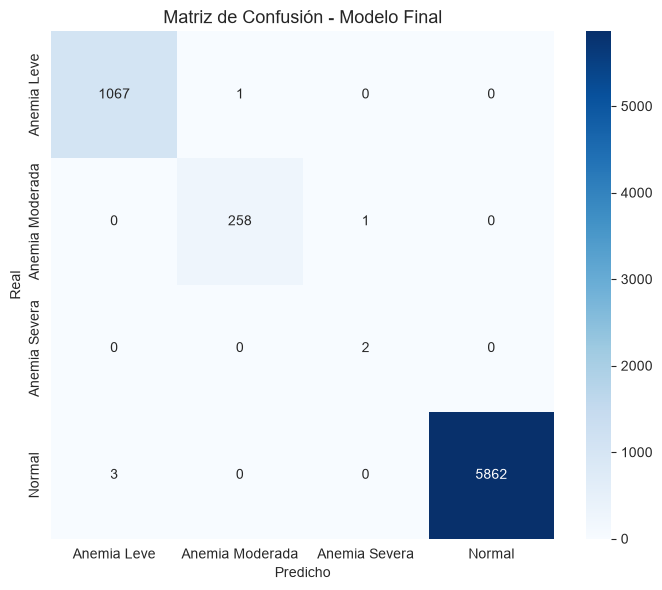

Interpretación: El modelo clasifica bien Normal y Anemia Leve. Anemia Severa es difícil por la escasez de datos.


In [29]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Modelo Final', fontsize=13)
plt.tight_layout()
plt.show()
print('Interpretación: El modelo clasifica bien Normal y Anemia Leve. Anemia Severa es difícil por la escasez de datos.')

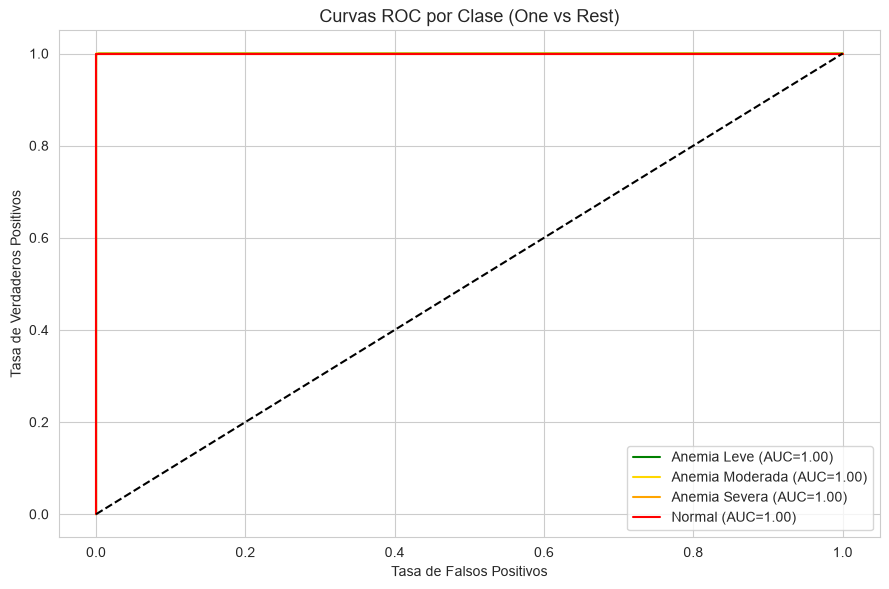

In [30]:
# Curva ROC (One vs Rest)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_prob = mejor_modelo.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(9, 6))
colors_roc = ['green', 'gold', 'orange', 'red']
for i, (cls, col) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, label=f'{cls} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC por Clase (One vs Rest)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## TAREA 12: Selección del Modelo Final

Se selecciona **Random Forest (Tuned con SMOTE)** como modelo final por:
- Mejor F1 Macro entre los modelos evaluados
- Buena estabilidad en validación cruzada (baja desviación estándar)
- Alta interpretabilidad mediante importancia de variables
- No requiere escalamiento de datos
- Tiempo de entrenamiento razonable para el tamaño del dataset

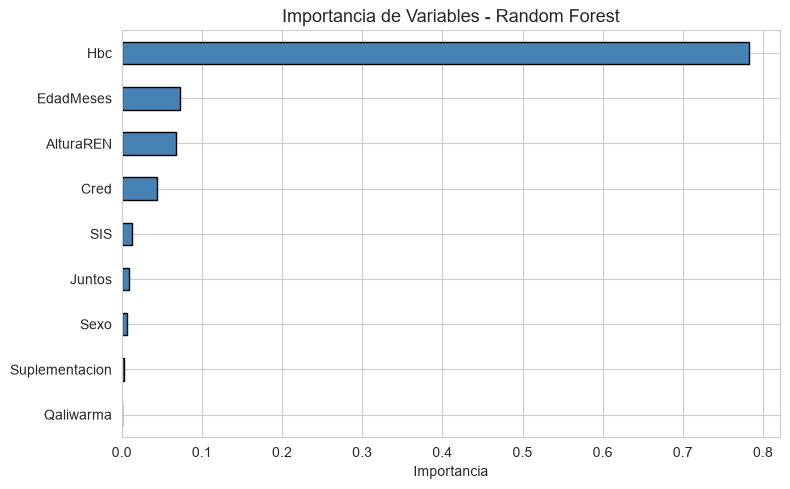

Hbc es la variable más determinante, seguida de AlturaREN y EdadMeses.


In [31]:
# Importancia de variables
importancias = pd.Series(mejor_modelo.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Importancia de Variables - Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()
print('Hbc es la variable más determinante, seguida de AlturaREN y EdadMeses.')

## TAREA 13: Exportación del Modelo

In [32]:
import joblib

# Guardar modelo y el encoder de etiquetas juntos
artefacto = {
    'modelo': mejor_modelo,
    'label_encoder': le,
    'features': list(X_train.columns)
}

joblib.dump(artefacto, '../models/modelo_final.pkl')
print('Modelo exportado en: ../models/modelo_final.pkl')

Modelo exportado en: ../models/modelo_final.pkl
